# Movie Recommendation System — MovieLens 20M

Popularity → content-based → collaborative filtering → hybrid → evaluation.
20,000,263 ratings, 138,493 users, 27,278 movies (1995–2015), plus user tags and the tag genome.

Put the extracted CSVs in a `data/` folder next to this notebook. Runs in ~3 minutes.

Two decisions that shape everything below: all matrices are `scipy.sparse` (a dense user–item matrix
is 14.8 GB here, the sparse one is 240 MB), and the split is **temporal per user** — each user's last
20% is held out, because a random split lets the model see a user's future to predict their past.

In [10]:
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

# --- configuration -----------------------------------------------------
DATA_DIR = Path("data")

MIN_MOVIE_RATINGS = 100   # below this a movie adds noise and inflates the O(n^2) similarity
USER_SAMPLE = 20_000      # None = all 138k users (needs ~8 GB RAM)
LIKE_THRESHOLD = 4.0      # rating >= this counts as "relevant" for the ranking metrics

ITEM_K = 100              # neighbours kept per item in the item-item similarity matrix
ITEM_SHRINK = 50          # similarity shrinkage strength (see the item-CF section)
MF_FACTORS = 64           # latent factors for the SVD matrix factorisation

# Hybrid blend weights (CF / content / popularity), grid-searched on NDCG@10
W_CF = 0.4
W_CONTENT = 0.2
W_POP = 0.4

TOP_K = 10                # cutoff for the ranking metrics (Precision@K, Recall@K, ...)
N_EVAL_USERS = 3_000      # users sampled for the ranking evaluation


## 1. Load, inspect, clean

`rating.csv` is 659 MB. Declaring dtypes and streaming the timestamp column keeps this near 300 MB
instead of ~2.5 GB. The tag genome (a relevance score per curated tag per movie) is the strongest
content signal in the dataset; thresholding at 0.5 keeps it sparse.

In [11]:
movies = pd.read_csv(DATA_DIR / "movie.csv")

# TMDB/IMDb IDs, for poster art in the dashboard -- not used by any model.
links = pd.read_csv(DATA_DIR / "link.csv", dtype={"movieId": "int32"})
movies = movies.merge(links, on="movieId", how="left")
ratings = pd.read_csv(
    DATA_DIR / "rating.csv",
    usecols=["userId", "movieId", "rating"],
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
)
tags = pd.read_csv(DATA_DIR / "tag.csv", usecols=["movieId", "tag"])

# Timestamps are streamed and converted to int32 Unix seconds -- 80 MB instead of
# ~1.3 GB if pandas were left to store 20M timestamp strings.
timestamp_chunks = []
for chunk in pd.read_csv(DATA_DIR / "rating.csv", usecols=["timestamp"],
                          dtype={"timestamp": "str"}, chunksize=2_000_000):
    parsed = pd.to_datetime(chunk["timestamp"], format="%Y-%m-%d %H:%M:%S")
    seconds_since_epoch = (parsed - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")
    timestamp_chunks.append(seconds_since_epoch.astype("int32").to_numpy())

ratings["ts"] = np.concatenate(timestamp_chunks)
del timestamp_chunks
gc.collect()

# The tag genome: a relevance score per (movie, curated tag). Thresholding at 0.5
# keeps only the tags that are actually descriptive of a movie, and keeps the
# resulting matrix sparse.
genome = pd.read_csv(
    DATA_DIR / "genome_scores.csv",
    dtype={"movieId": "int32", "tagId": "int32", "relevance": "float32"},
)
genome = genome[genome["relevance"] >= 0.5].copy()
gc.collect()

# --- data quality checks ------------------------------------------------
print("missing values:")
for name, table in [("movies", movies), ("ratings", ratings), ("tags", tags)]:
    missing = table.isna().sum()
    missing = missing[missing > 0]
    print(f"  {name:8s}", dict(missing) if len(missing) else "none")

print(f"duplicate (userId, movieId) pairs : {ratings.duplicated(['userId', 'movieId']).sum():,}")
print(f"duplicate movie titles            : {movies['title'].duplicated().sum():,}")
print(f"ratings on unknown movieId        : {(~ratings['movieId'].isin(set(movies['movieId']))).sum():,}")

# --- clean the movie table ----------------------------------------------
NO_GENRE = "(no genres listed)"

# Titles embed the release year, e.g. "Toy Story (1995)" -- split it into its own column.
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)\s*$")[0].astype("float32")
movies["clean_title"] = movies["title"].str.replace(r"\s*\(\d{4}\)\s*$", "", regex=True)

# "(no genres listed)" is a sentinel, not a genre -- normalise it to an empty list.
movies["genre_list"] = (
    movies["genres"]
    .where(movies["genres"] != NO_GENRE, "")
    .str.split("|")
    .apply(lambda genre_list: [g for g in genre_list if g])
)

print(f"\nmovies missing a year: {movies['year'].isna().sum():,} | "
      f"no genres listed: {(movies['genre_list'].str.len() == 0).sum():,}")


missing values:
  movies   {'tmdbId': np.int64(252)}
  ratings  none
  tags     {'tag': np.int64(16)}
duplicate (userId, movieId) pairs : 0
duplicate movie titles            : 16
ratings on unknown movieId        : 0

movies missing a year: 26 | no genres listed: 246


**Findings.** No missing values in ratings or movies, and **zero duplicate (user, movie) pairs** —
MovieLens enforces one rating per user per film, so there is nothing to deduplicate. The 16 duplicate
titles are different films sharing a name (remakes); they keep separate IDs and separate histories.
The 26 unparseable years and 246 genre-less movies are left missing rather than imputed — a fabricated
release year would silently corrupt any year filtering downstream.

## 2. Exploration

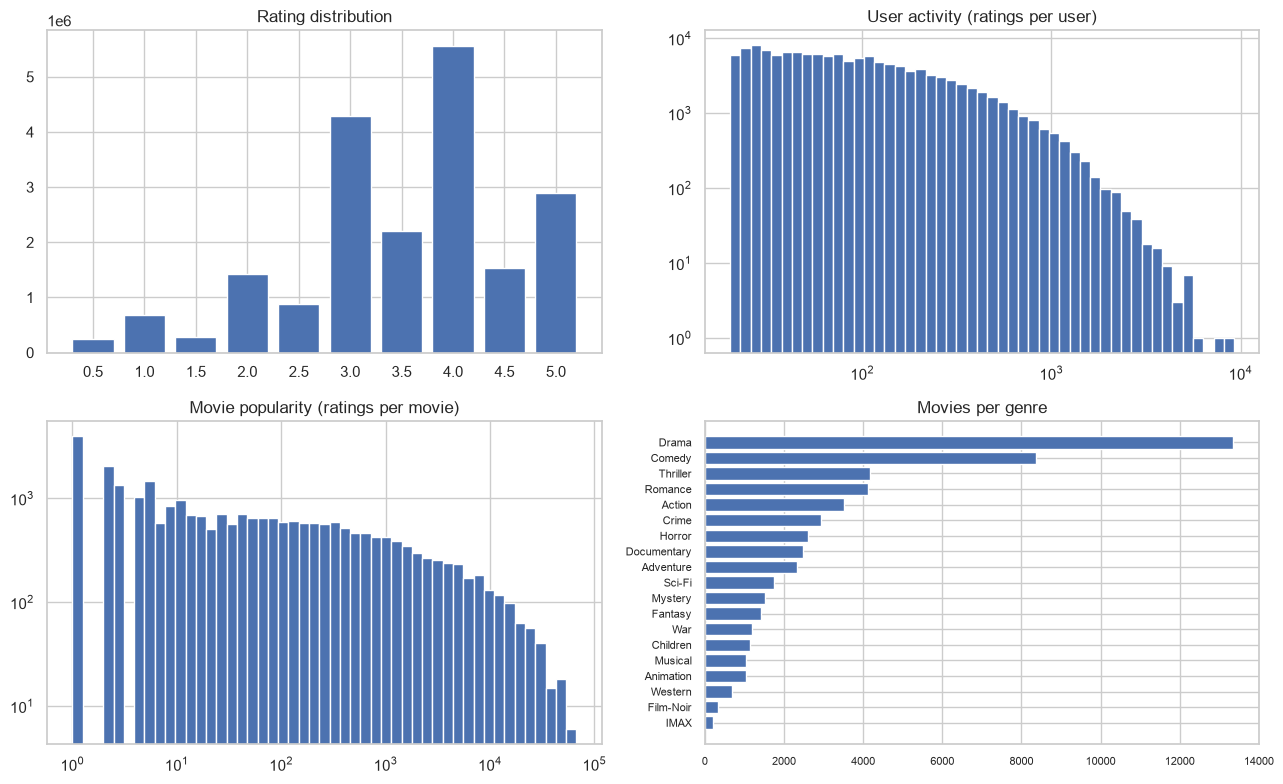

mean rating 3.526 | share >= 4.0: 50.0%
ratings per user  : median 68, max 9,254
ratings per movie : median 18, max 67,310
top 5% of movies hold 71.4% of all ratings

MOST-RATED


,title,count,mean
movieId,,,
296,Pulp Fiction (1994),67310,4.174231
356,Forrest Gump (1994),66172,4.029000
318,"Shawshank Redemption, The (1994)",63366,4.446990
593,"Silence of the Lambs, The (1991)",63299,4.177056
480,Jurassic Park (1993),59715,3.664741
260,Star Wars: Episode IV - A New Hope (1977),54502,4.190672


HIGHEST-RATED, no minimum -- why a raw average is useless


,title,count,mean
movieId,,,
26718,Life On A String (Bian chang Bian Zou) (1991),1,5.0
27914,"Hijacking Catastrophe: 9/11, Fear & the Sellin...",1,5.0
32230,"Snow Queen, The (Lumikuningatar) (1986)",1,5.0
40404,Al otro lado (2004),1,5.0


HIGHEST-RATED with >= 1000 ratings


,title,count,mean
movieId,,,
318,"Shawshank Redemption, The (1994)",63366,4.446990
858,"Godfather, The (1972)",41355,4.364732
50,"Usual Suspects, The (1995)",47006,4.334372
527,Schindler's List (1993),50054,4.310175
1221,"Godfather: Part II, The (1974)",27398,4.275640
2019,Seven Samurai (Shichinin no samurai) (1954),11611,4.274179


In [12]:
user_counts = ratings["userId"].value_counts()
movie_counts = ratings["movieId"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

rating_dist = ratings["rating"].value_counts().sort_index()
axes[0, 0].bar(rating_dist.index.astype(str), rating_dist.values)
axes[0, 0].set_title("Rating distribution")

axes[0, 1].hist(user_counts.values,
                 bins=np.logspace(np.log10(20), np.log10(user_counts.max()), 50))
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("User activity (ratings per user)")

axes[1, 0].hist(movie_counts.values,
                 bins=np.logspace(0, np.log10(movie_counts.max()), 50))
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Movie popularity (ratings per movie)")

genre_counts = movies.explode("genre_list")["genre_list"].value_counts()
axes[1, 1].barh(genre_counts.index[::-1], genre_counts.values[::-1])
axes[1, 1].set_title("Movies per genre")
axes[1, 1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# --- summary numbers ------------------------------------------------------
sorted_counts_desc = np.sort(movie_counts.values)[::-1]
top_5pct_cutoff = int(len(sorted_counts_desc) * 0.05)

print(f"mean rating {ratings['rating'].mean():.3f} | share >= {LIKE_THRESHOLD}: "
      f"{(ratings['rating'] >= LIKE_THRESHOLD).mean():.1%}")
print(f"ratings per user  : median {user_counts.median():.0f}, max {user_counts.max():,}")
print(f"ratings per movie : median {movie_counts.median():.0f}, max {movie_counts.max():,}")
print(f"top 5% of movies hold "
      f"{np.cumsum(sorted_counts_desc)[top_5pct_cutoff] / sorted_counts_desc.sum():.1%} "
      f"of all ratings")

# --- most-rated and highest-rated movies -----------------------------------
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(count="count", mean="mean")
    .join(movies.set_index("movieId")["title"])
)

print("\nMOST-RATED")
display(movie_stats.nlargest(6, "count")[["title", "count", "mean"]])

print("HIGHEST-RATED, no minimum -- why a raw average is useless")
display(movie_stats.nlargest(4, "mean")[["title", "count", "mean"]])

print("HIGHEST-RATED with >= 1000 ratings")
display(movie_stats[movie_stats["count"] >= 1000].nlargest(6, "mean")[["title", "count", "mean"]])


**Read.** Ratings are strongly left-skewed (mean ≈ 3.53) — the positivity bias of voluntary rating
data. Predicting that mean alone already gives RMSE ≈ 1.03, so report the baseline next to every RMSE
below. Both count distributions are heavy-tailed: the median movie has 18 ratings, the most-rated has
67,310, and 5% of the catalogue absorbs 71% of all ratings. That drives two decisions — popularity
will be a respectable baseline, and similarity computed on rarely-rated films is unreliable (fixed
with shrinkage in section 5). The raw-average leaderboard is all films with a single 5-star rating,
which is exactly what the weighted rating below fixes.

## 3. Modelling matrix, split, and the popularity baseline

Filters: movies with ≥ 100 ratings (8,546 of 26,744 survive, holding 98.5% of all ratings — a 10×
cut in the O(n²) similarity cost for almost no information loss), then a sample of 20,000 **users**
(sampling users preserves whole rating histories; sampling rows would shred them).

For the baseline itself, a raw average is dominated by films with a handful of ratings, so we use the
Bayesian weighted rating, which shrinks each average toward the global mean in proportion to how
little evidence supports it:

$$\text{WR}(i) = \frac{v_i}{v_i + m}\,\bar r_i + \frac{m}{v_i + m}\,\mu$$

A film with 5 ratings is pulled almost entirely to $\mu$; one with 50,000 keeps its own average. The
same shrinkage idea reappears in the similarity weights and the bias model below.

In [13]:
# --- subset: drop rarely-rated movies, then sample users ------------------
movie_rating_counts = ratings["movieId"].value_counts()
kept_movie_ids = set(movie_rating_counts[movie_rating_counts >= MIN_MOVIE_RATINGS].index)
df = ratings[ratings["movieId"].isin(kept_movie_ids)]

if USER_SAMPLE:
    all_user_ids = df["userId"].unique()
    if USER_SAMPLE < len(all_user_ids):
        sampled_user_ids = rng.choice(all_user_ids, USER_SAMPLE, replace=False)
        df = df[df["userId"].isin(set(sampled_user_ids))]

df = df.copy()

# --- map raw IDs to contiguous 0..n-1 matrix indices -----------------------
uids = np.sort(df["userId"].unique())
mids = np.sort(df["movieId"].unique())
user_id_to_index = {user_id: i for i, user_id in enumerate(uids)}
movie_id_to_index = {movie_id: i for i, movie_id in enumerate(mids)}

df["ui"] = df["userId"].map(user_id_to_index).astype("int32")
df["mi"] = df["movieId"].map(movie_id_to_index).astype("int32")

n_users, n_items = len(uids), len(mids)
title_of = movies.set_index("movieId")["title"].reindex(mids).to_numpy()
genres_of = movies.set_index("movieId")["genres"].reindex(mids).to_numpy()

# --- temporal split: each user's earliest 80% trains, most recent 20% tests ---
df = df.sort_values(["ui", "ts"], kind="mergesort").reset_index(drop=True)
grouped_by_user = df.groupby("ui", sort=True)
position_in_history = grouped_by_user.cumcount()
history_length = grouped_by_user["ui"].transform("size")
is_test_row = (position_in_history >= np.ceil(history_length * 0.8)).to_numpy()

train = df[~is_test_row].reset_index(drop=True)
test = df[is_test_row].reset_index(drop=True)

# --- sparse user-item rating matrix (train only) ---------------------------
R = sp.csr_matrix(
    (train["rating"].to_numpy(), (train["ui"].to_numpy(), train["mi"].to_numpy())),
    shape=(n_users, n_items),
    dtype=np.float32,
)
R.sort_indices()

R_mask = R.copy()
R_mask.data = np.ones_like(R_mask.data)   # binary "was this rated" version of R

te_u = test["ui"].to_numpy()
te_i = test["mi"].to_numpy()
te_r = test["rating"].to_numpy()

# --- popularity baseline: number of ratings, average rating, weighted score ---
R_csc = R.tocsc()
pop_count = np.diff(R_csc.indptr).astype(np.float32)
pop_mean = (np.asarray(R_csc.sum(axis=0)).ravel() / np.maximum(pop_count, 1)).astype(np.float32)

MU = float(R.data.mean())                                        # global mean rating
m_prior = float(np.quantile(pop_count[pop_count > 0], 0.80))     # shrinkage prior strength

# Bayesian-weighted rating: shrinks each movie's average toward the global mean,
# in proportion to how little evidence (how few ratings) supports it.
pop_score = (
    (pop_count / (pop_count + m_prior)) * pop_mean
    + (m_prior / (pop_count + m_prior)) * MU
).astype(np.float32)

print(f"{n_users:,} users x {n_items:,} movies | density {R.nnz / (n_users * n_items):.3%}")
print(f"train {len(train):,} | test {len(test):,} | global mean {MU:.4f}\n")

top = np.argsort(-pop_score)[:8]
display(pd.DataFrame({
    "title": title_of[top],
    "n_ratings": pop_count[top].astype(int),
    "raw_avg": pop_mean[top].round(3),
    "weighted": pop_score[top].round(3),
}))


20,000 users x 8,546 movies | density 1.342%
train 2,293,883 | test 563,895 | global mean 3.5504



,title,n_ratings,raw_avg,weighted
0,"Shawshank Redemption, The (1994)",8272,4.447,4.416
1,"Godfather, The (1972)",5253,4.361,4.319
2,"Usual Suspects, The (1995)",6019,4.339,4.303
3,Schindler's List (1993),6393,4.300,4.268
4,Dr. Strangelove or: How I Learned to Stop Worr...,2968,4.285,4.220
5,Casablanca (1942),3090,4.282,4.220
6,Rear Window (1954),2138,4.302,4.213
7,"Godfather: Part II, The (1974)",3437,4.264,4.209


The one-rating curiosities are gone without an arbitrary `count >= 1000` cutoff. This is the
number every other model has to beat, and the fallback when a personalised model has nothing to work
with.

## 4. Content-based recommendation

Four blocks per movie, concatenated and L2-normalised: TF-IDF over genres, over the aggregated user
tags, over title tokens (low weight — mostly noise, but catches franchises), and the tag genome.

**Why TF-IDF rather than one-hot on genres?** One-hot treats "Drama" (13,344 films) as equally
informative as "Film-Noir" (330). IDF down-weights common labels automatically, so two film-noirs are
correctly judged more similar than two dramas.

Features cover **all 27,278 movies**, not just the 8,546 in the CF model — content is the only signal
available for a film nobody has rated, so it must span the whole catalogue for cold start to work.

In [14]:
# --- build content features: genres + tags + title + tag genome -----------
tags["tag"] = tags["tag"].fillna("").astype(str).str.lower()
tag_text_by_movie = tags.groupby("movieId")["tag"].agg(" ".join)
movies["tag_text"] = movies["movieId"].map(tag_text_by_movie).fillna("")

# Strip the sentinel and hyphens so "Sci-Fi" tokenises as one clean word.
genre_text = (
    movies["genres"]
    .str.replace(NO_GENRE, "", regex=False)
    .str.replace("|", " ", regex=False)
    .str.replace("-", "", regex=False)
)

row_of_movie = {movie_id: i for i, movie_id in enumerate(movies["movieId"])}

X_genre = TfidfVectorizer(token_pattern=r"[^\s]+").fit_transform(genre_text)
X_tag = TfidfVectorizer(
    stop_words="english", max_features=20_000, ngram_range=(1, 2), min_df=2,
).fit_transform(movies["tag_text"])
X_title = TfidfVectorizer(stop_words="english", max_features=8_000).fit_transform(movies["clean_title"])

genome_rows = genome["movieId"].map(row_of_movie).to_numpy()
genome_cols = genome["tagId"].to_numpy() - 1
X_genome = sp.csr_matrix(
    (genome["relevance"].to_numpy(), (genome_rows, genome_cols)),
    shape=(len(movies), genome["tagId"].max()),
    dtype=np.float32,
)

# Concatenate all four blocks (each L2-normalised first, then weighted) into one
# content matrix, then L2-normalise the combined result.
C_all = normalize(sp.hstack([
    normalize(X_genre) * 1.0,
    normalize(X_tag) * 0.8,
    normalize(X_title) * 0.3,
    normalize(X_genome) * 1.0,
]).tocsr()).astype(np.float32)


def similar_movies(movie_id, n=6):
    """Cosine similarity computed on demand -- a full 27,278^2 matrix would need 3 GB."""
    row = row_of_movie[movie_id]
    similarities = np.asarray((C_all[row] @ C_all.T).todense()).ravel()
    similarities[row] = -np.inf

    top = np.argpartition(-similarities, n)[:n]
    top = top[np.argsort(-similarities[top])]

    return pd.DataFrame({
        "title": movies["title"].to_numpy()[top],
        "genres": movies["genres"].to_numpy()[top],
        "similarity": similarities[top].round(4),
    })


print(f"content matrix {C_all.shape}, {C_all.nnz:,} non-zeros")
for title in ["Toy Story (1995)", "Godfather, The (1972)", "Shining, The (1980)"]:
    movie_id = int(movies.loc[movies["title"] == title, "movieId"].iloc[0])
    print(f"\n### Similar to {title}")
    display(similar_movies(movie_id))


content matrix (27278, 29147), 976,574 non-zeros

### Similar to Toy Story (1995)


,title,genres,similarity
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.9153
1,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.8539
2,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.8074
3,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.7760
4,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.7616
5,Ice Age (2002),Adventure|Animation|Children|Comedy,0.7524



### Similar to Godfather, The (1972)


,title,genres,similarity
0,"Godfather: Part II, The (1974)",Crime|Drama,0.9054
1,Goodfellas (1990),Crime|Drama,0.7672
2,On the Waterfront (1954),Crime|Drama,0.7136
3,Carlito's Way (1993),Crime|Drama,0.7025
4,Dog Day Afternoon (1975),Crime|Drama,0.6973
5,Scarface (1983),Action|Crime|Drama,0.6970



### Similar to Shining, The (1980)


,title,genres,similarity
0,Oculus (2013),Horror,0.6385
1,Pet Sematary (1989),Horror,0.6290
2,Starry Eyes (2014),Horror,0.6284
3,Pin... (1988),Horror,0.6052
4,Nightwing (1979),Horror,0.6052
5,HazMat (2013),Horror,0.6052


**The third example is the failure mode.** *Toy Story* returns the Pixar catalogue and
*The Godfather* returns the crime-drama canon (including Goodfellas, which shares no title tokens —
the genome doing real work). But *The Shining* returns obscure horror films, because content
similarity has **no concept of quality or demand**: "horror film with these tags" is satisfied equally
by a classic and by a direct-to-video release nobody has seen. That is the strongest practical
argument for the hybrid — content knows what a film is *like*, collaborative filtering knows whether
anyone actually *wants* it.

## 5. Collaborative filtering

**Bias model first.** Some users are generous, some films are good; remove that systematic part before
anything else:

$$\hat r_{ui} = \mu + b_u + b_i + (\text{interaction})$$

$b_u$ and $b_i$ are fit by alternating ridge regression — two `np.bincount` calls per iteration. The
residual is what everything below learns from. **Computing similarity on raw ratings instead of
residuals is the most common bug in this project**: it makes every generous user look similar to every
other generous user.

**Item-based CF.** Cosine between items' residual vectors, with shrinkage:

$$s_{ij} = \frac{\sum_u \tilde r_{ui}\tilde r_{uj}}{\|\tilde r_{\cdot i}\|\|\tilde r_{\cdot j}\|}
\cdot \frac{n_{ij}}{n_{ij}+\beta}$$

**The shrinkage is not optional.** Without it two films rated by the same 3 users score 1.0 on no real
evidence, and those spurious values dominate every neighbour list. This one term moved RMSE from
**0.8852 → 0.8311**, a bigger gain than doubling the MF factors. The full matrix would be 292 MB (2.9
GB on the whole catalogue), so it is built in column blocks keeping the top 100 neighbours per item.

*(User-based CF is the natural counterpart but is omitted: the user–user matrix is 19,942² here and
77 GB on the full dataset, so it cannot be precomputed, and in testing it did not beat the bias
baseline.)*

**Matrix factorisation.** $\tilde R \approx U\Sigma V^\top$, giving 64 latent taste axes discovered
from the data with no genre labels involved — and the only approach here that can relate two films
with zero co-raters. Caveat: `svds` treats unobserved entries as exact zeros. Since we factorise the
*residual*, a zero means "this user would rate this film at their baseline" — defensible, but an
assumption. FunkSVD or ALS would sum only over observed entries.

In [15]:
def fit_bias(R, reg_user=10.0, reg_item=25.0, n_iter=12):
    """Alternating ridge fit of a global mean plus per-user and per-item biases."""
    coo = R.tocoo()
    user_idx, item_idx, rating = coo.row, coo.col, coo.data
    mu = float(rating.mean())

    b_u = np.zeros(R.shape[0], np.float32)
    b_i = np.zeros(R.shape[1], np.float32)
    count_per_user = np.bincount(user_idx, minlength=R.shape[0])
    count_per_item = np.bincount(item_idx, minlength=R.shape[1])

    for _ in range(n_iter):
        item_residual = rating - mu - b_u[user_idx]
        b_i = (np.bincount(item_idx, weights=item_residual, minlength=R.shape[1])
               / (reg_item + count_per_item)).astype(np.float32)

        user_residual = rating - mu - b_i[item_idx]
        b_u = (np.bincount(user_idx, weights=user_residual, minlength=R.shape[0])
               / (reg_user + count_per_user)).astype(np.float32)

    return mu, b_u, b_i


MU, B_USER, B_ITEM = fit_bias(R)

# Residual matrix: ratings with the systematic user/item effects removed. Every
# similarity and factorisation below works on this, not on the raw ratings --
# computing similarity on raw ratings is the most common bug in this kind of
# project, since it makes every generous user look similar to every other one.
coo = R.tocoo()
residual = (coo.data - (MU + B_USER[coo.row] + B_ITEM[coo.col])).astype(np.float32)
R_res = sp.csr_matrix((residual, (coo.row, coo.col)), shape=R.shape)
R_res.sort_indices()


def build_item_similarity(k=ITEM_K, shrink=ITEM_SHRINK, block=600):
    """Top-k shrunk cosine similarity between items, computed in column blocks."""
    residual_csc = R_res.tocsc()
    mask_csc = R_mask.tocsc()

    norms = np.sqrt(np.asarray(residual_csc.multiply(residual_csc).sum(axis=0)).ravel()) + 1e-8
    unit = residual_csc.multiply(sp.csr_matrix(1.0 / norms)).tocsc().astype(np.float32)

    rows, cols, vals = [], [], []
    for start in range(0, n_items, block):
        end = min(start + block, n_items)

        similarity_block = (unit[:, start:end].T @ unit).toarray()
        co_rating_counts = (mask_csc[:, start:end].T @ mask_csc).toarray()
        similarity_block *= co_rating_counts / (co_rating_counts + shrink)  # shrink toward 0
        similarity_block[np.arange(end - start), np.arange(start, end)] = -np.inf  # drop self

        top_k_idx = np.argpartition(-similarity_block, k, axis=1)[:, :k]
        top_k_val = np.take_along_axis(similarity_block, top_k_idx, axis=1)
        keep = (top_k_val > 0).ravel()   # negative similarity carries no signal, treat as noise

        rows.append(np.repeat(np.arange(start, end), k)[keep])
        cols.append(top_k_idx.ravel()[keep])
        vals.append(top_k_val.ravel()[keep])
        del similarity_block, co_rating_counts

    return sp.csr_matrix(
        (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
        shape=(n_items, n_items), dtype=np.float32,
    )


S_item = build_item_similarity()
S_item_T = S_item.T.tocsr()
S_item_abs_T = abs(S_item).T.tocsr()


def itemcf_scores(user_idx):
    """Dense ranking scores over all items for a batch of users."""
    return (R_res[user_idx] @ S_item_T).toarray()


def itemcf_predict(u_idx, i_idx, block=1000):
    """Rating prediction for arbitrary (user, item) pairs, batched over users."""
    out = np.zeros(len(u_idx), np.float32)
    for start in range(0, n_users, block):
        end = min(start + block, n_users)
        in_block = (u_idx >= start) & (u_idx < end)
        if not in_block.any():
            continue

        numerator = (R_res[start:end] @ S_item_T).toarray()
        denominator = (R_mask[start:end] @ S_item_abs_T).toarray()

        local_u, item = u_idx[in_block] - start, i_idx[in_block]
        d = denominator[local_u, item]
        out[in_block] = np.where(d > 1e-6, numerator[local_u, item] / np.maximum(d, 1e-6), 0.0)
        del numerator, denominator

    return np.clip(MU + B_USER[u_idx] + B_ITEM[i_idx] + out, 0.5, 5.0)


# --- matrix factorisation: truncated SVD on the bias-corrected residual matrix ---
U, sigma, Vt = svds(R_res, k=MF_FACTORS)
order = np.argsort(-sigma)   # svds returns singular values in ascending order
P = (U[:, order] * sigma[order]).astype(np.float32)
Q = Vt[order].T.astype(np.float32)


def mf_scores(user_idx):
    return P[user_idx] @ Q.T


def mf_predict(u_idx, i_idx):
    interaction = np.einsum("ij,ij->i", P[u_idx], Q[i_idx])
    return np.clip(MU + B_USER[u_idx] + B_ITEM[i_idx] + interaction, 0.5, 5.0)


print(f"{S_item.nnz:,} similarity entries | factors P {P.shape}, Q {Q.shape}")

probe_movie = int(np.flatnonzero(title_of == "Godfather, The (1972)")[0])
probe_row = S_item[probe_movie].toarray().ravel()
neighbour_idx = np.argsort(-probe_row)[:6]
print("\nUsers who rated 'The Godfather' highly also rated:")
display(pd.DataFrame({
    "title": title_of[neighbour_idx],
    "similarity": probe_row[neighbour_idx].round(4),
}))


854,016 similarity entries | factors P (20000, 64), Q (8546, 64)

Users who rated 'The Godfather' highly also rated:


,title,similarity
0,"Godfather: Part II, The (1974)",0.4885
1,Goodfellas (1990),0.1399
2,One Flew Over the Cuckoo's Nest (1975),0.1195
3,Casablanca (1942),0.1138
4,Psycho (1960),0.1093
5,Taxi Driver (1976),0.1044


Compare that with the content list for the same film: content gave the crime-drama canon by
*description*, item-CF gives what the same *audience* gravitates to — co-occurrence signal content can
never see.

## 6. Hybrid recommendation

### How the two approaches are combined

A **weighted score-level blend with a switching fallback**. The components are on incompatible scales
— item-CF outputs residual deviations roughly in [-1, 1], content outputs cosines in [0, 1],
popularity sits near 3.5 in rating units — so adding them directly would let whichever has the largest
raw variance dominate for reasons unrelated to quality. Each is z-normalised **within a user's
candidate set** first:

$$z_m(u,i) = \frac{s_m(u,i)-\bar s_m(u)}{\sigma_m(u)+\epsilon}, \qquad
s_{\text{hybrid}} = w_{cf}z_{cf} + w_{cb}z_{cb} + w_{pop}z_{pop}$$

Normalising per user rather than globally makes the weights mean "how much do I trust each signal for
this user". The weights (0.4 / 0.2 / 0.4) came from a grid search on NDCG@10; the surface is flat near
the optimum, which is reassuring — a hybrid that is razor-sharp in one corner of weight space is
usually overfitting the evaluation set. Blending scores rather than fusing ranked lists preserves
magnitude, which rank fusion discards.

### Why the hybrid may perform better

Each component fails in a way the others do not, and the failures are **uncorrelated** — the
precondition for ensembling to help at all:

| Model | Fails when | Because |
|---|---|---|
| Popularity | always, for personalisation | one list for everyone |
| Content | the item is obscure or badly tagged | no notion of quality or demand |
| Item-CF | the item is new or rarely rated | no co-rating evidence exists |
| MF | the user is new | no learned factor vector |

Concretely: content returned obscure horror films for *The Shining* because it cannot tell a classic
from a direct-to-video release — popularity can. Item-CF is strong in the head and silent in the tail,
where content still has genre and genome signal. The blend also **regularises**: an item needs support
from more than one signal to reach the top, which suppresses each model's single-signal artefacts.

### What happens when a new user or new movie has insufficient data

Three distinct problems that get conflated under one name.

**New user (no ratings).** Every personalised model is *undefined*, not merely inaccurate. The system
**switches** rather than blends: serve the popularity ranking, optionally filtered by anything stated
at signup, then transition progressively — a handful of ratings makes a content profile viable, around
20 makes a CF neighbourhood meaningful.

**New movie (no ratings).** Invisible to item-CF and MF, which both need co-rating evidence. Content
is the answer, which is why features cover all 27,278 movies: a brand-new film still has genres, a
title and a genome vector, so it can be placed in content space on day one.

**Sparse user (a few ratings).** Handled by the shrinkage terms already present throughout — $b_u$ for
a 5-rating user is pulled toward 0, similarity on 3 co-ratings is pulled toward 0. The model degrades
toward the population average instead of making confident nonsense. That graceful degradation is a
design property, not an accident.

In [16]:
def zscore(x):
    """z-score each row of a 2-D score matrix independently."""
    return (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)


# Content matrix restricted to the CF item order (only the movies in the model),
# used to build each user's taste profile.
C_model = normalize(C_all[[row_of_movie[m] for m in mids]]).astype(np.float32)

liked = train[train["rating"] >= LIKE_THRESHOLD]
L = sp.csr_matrix(
    (np.ones(len(liked), np.float32), (liked["ui"].to_numpy(), liked["mi"].to_numpy())),
    shape=(n_users, n_items),
)
USER_PROFILES = normalize(L @ C_model).astype(np.float32)   # centroid of each user's liked items
POP_Z = zscore(pop_score[None, :])[0]


def content_scores(user_idx):
    return (USER_PROFILES[user_idx] @ C_model.T).toarray()


def hybrid_scores(user_idx):
    return (
        W_CF * zscore(itemcf_scores(user_idx))
        + W_CONTENT * zscore(content_scores(user_idx))
        + W_POP * np.tile(POP_Z, (len(user_idx), 1))
    )


def recommend(u, n=8):
    """Switches recommendation strategy based on how much we know about the user."""
    seen = set(R[u].indices)

    if len(seen) == 0:
        strategy = "popularity (cold user)"
        scores = pop_score.copy()
    elif len(seen) < 5 or USER_PROFILES[u].nnz == 0:
        strategy = f"content + popularity (sparse user, {len(seen)} ratings)"
        scores = 0.5 * zscore(content_scores([u]))[0] + 0.5 * POP_Z
    else:
        strategy = f"full hybrid ({len(seen)} ratings)"
        scores = hybrid_scores(np.array([u]))[0]

    scores = scores.copy()
    scores[list(seen)] = -np.inf
    top = np.argsort(-scores)[:n]

    print(f"user {u}: {strategy}")
    return pd.DataFrame({
        "title": title_of[top],
        "genres": genres_of[top],
        "score": scores[top].round(3),
    })


# --- demo: a warm user with plenty of history -------------------------------
warm_user = int(train["ui"].value_counts().index[0])
warm_user_liked = train[(train["ui"] == warm_user) & (train["rating"] >= 4.5)]["mi"].to_numpy()[:6]

print(f"user {warm_user} rated these 4.5+ in train:")
display(pd.DataFrame({"title": title_of[warm_user_liked]}))
display(recommend(warm_user))

# --- demo: a cold movie, with no CF evidence at all, placed by content alone ---
genome_tag_count = np.diff(X_genome.tocsr().indptr)
cold_movies = movies[(~movies["movieId"].isin(set(mids))) & (genome_tag_count > 0)].copy()
cold_movies["genome_tags"] = genome_tag_count[cold_movies.index]

cold_pick = cold_movies.nlargest(1, "genome_tags").iloc[0]
print(f"\ncold movie (too few ratings for the CF model): {cold_pick['title']} | {cold_pick['genres']}")
display(similar_movies(int(cold_pick["movieId"]), 5))


user 12118 rated these 4.5+ in train:


,title
0,"X-Files: Fight the Future, The (1998)"
1,"Usual Suspects, The (1995)"
2,Cinema Paradiso (Nuovo cinema Paradiso) (1989)
3,Chinatown (1974)
4,Good Will Hunting (1997)
5,Blade Runner (1982)


user 12118: full hybrid (3590 ratings)


,title,genres,score
0,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,2.323
1,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,2.116
2,All the President's Men (1976),Drama|Thriller,1.995
3,"Departed, The (2006)",Crime|Drama|Thriller,1.902
4,"Pianist, The (2002)",Drama|War,1.866
5,Close Encounters of the Third Kind (1977),Adventure|Drama|Sci-Fi,1.864
6,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,1.792
7,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller,1.752



cold movie (too few ratings for the CF model): Ascension (2014) | Drama|Sci-Fi


,title,genres,similarity
0,Babylon 5,Sci-Fi,0.6713
1,Black Mirror (2011),Drama|Sci-Fi,0.6494
2,Riverworld (2010),Drama|Sci-Fi,0.6052
3,Conceiving Ada (1997),Drama|Sci-Fi,0.6052
4,"Goodbye, 20th Century (1998)",Drama|Sci-Fi,0.5797


## 7. Evaluation

Two regimes, because they reward different things and **disagree about which model is best**.

**Rating prediction** (RMSE, MAE): given that a user rated a film, how close is the prediction?

**Top-N ranking** (Precision@K, Recall@K, Hit Rate, MAP@K, NDCG@K): of the 10 films we would actually
show, how many did the user go on to rate ≥ 4.0? This is the one that matches the product — nobody
sees a predicted rating, they see a shelf of ten posters.

Ranking protocol: for each of 3,000 sampled test users, score all 8,546 items, mask everything they
rated in train, take the top 10, compare against their held-out items rated ≥ 4.0. Strict all-items
protocol — no negative sampling, which inflates every number and is a known source of unreproducible
results.

RATING PREDICTION


,RMSE,MAE
Item-based CF,0.8311,0.6218
MF-SVD (k=64),0.8443,0.6426
Bias baseline,0.8603,0.6569
Item mean (shrunk),0.9312,0.7220
Global mean,1.0348,0.8210



TOP-10 RANKING


,P@10,Recall@10,HitRate@10,MAP@10,NDCG@10
Hybrid,0.0896,0.0894,0.4677,0.0612,0.1189
Item-based CF,0.0786,0.0778,0.4350,0.0535,0.1058
MF-SVD,0.0586,0.0562,0.3557,0.0376,0.0783
Popularity,0.0424,0.0399,0.2617,0.0279,0.0574
Content-based,0.0360,0.0352,0.2567,0.0217,0.0486


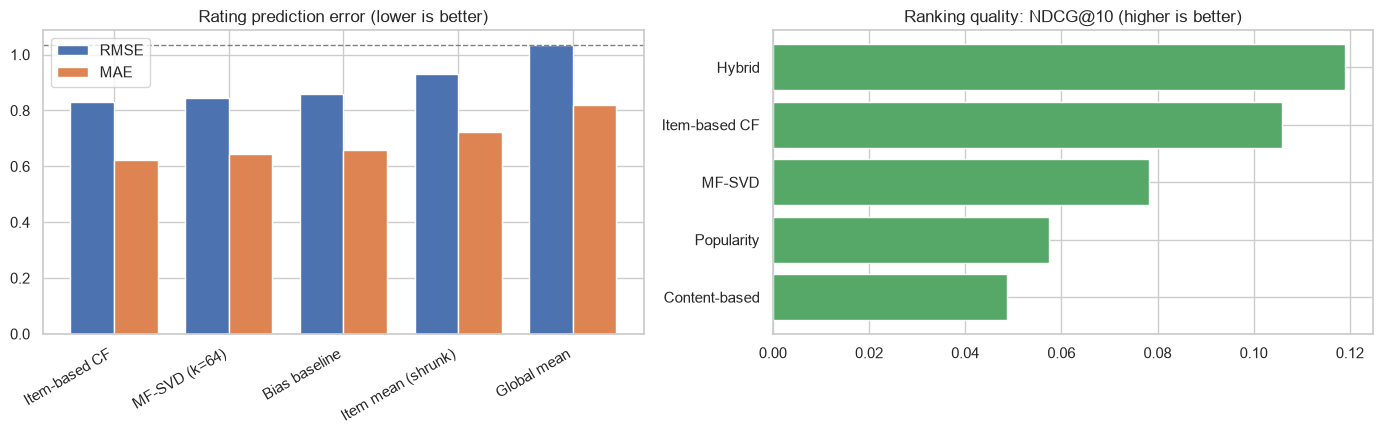

In [17]:
def rmse(predicted, actual):
    return float(np.sqrt(np.mean((predicted - actual) ** 2)))


def mae(predicted, actual):
    return float(np.mean(np.abs(predicted - actual)))


# --- rating-prediction comparison -------------------------------------------
item_mean_shrunk = (
    (np.asarray(R.sum(axis=0)).ravel() + 10 * MU) / (np.diff(R.tocsc().indptr) + 10)
).astype(np.float32)

rating_predictions = {
    "Global mean":        np.full_like(te_r, MU),
    "Item mean (shrunk)": np.clip(item_mean_shrunk[te_i], 0.5, 5.0),
    "Bias baseline":      np.clip(MU + B_USER[te_u] + B_ITEM[te_i], 0.5, 5.0),
    "MF-SVD (k=64)":      mf_predict(te_u, te_i),
    "Item-based CF":      itemcf_predict(te_u, te_i),
}
rating_results = {
    name: (rmse(pred, te_r), mae(pred, te_r)) for name, pred in rating_predictions.items()
}


# --- ranking metrics ---------------------------------------------------------
def ranking_metrics(ranked, relevant, k):
    """Precision@k, Recall@k, HitRate@k, AP@k, NDCG@k for one user."""
    is_relevant = np.fromiter(
        (1.0 if item in relevant else 0.0 for item in ranked[:k]), np.float64, k,
    )
    hits = is_relevant.sum()

    if hits > 0:
        cumulative_hits = np.cumsum(is_relevant)
        average_precision = np.sum(cumulative_hits / np.arange(1, k + 1) * is_relevant) \
            / min(len(relevant), k)
    else:
        average_precision = 0.0

    discount = 1.0 / np.log2(np.arange(2, k + 2))
    ideal_discount = discount[:min(len(relevant), k)].sum()
    ndcg = (is_relevant * discount).sum() / ideal_discount if ideal_discount > 0 else 0.0

    precision = hits / k
    recall = hits / len(relevant)
    hit_rate = 1.0 if hits > 0 else 0.0
    return precision, recall, hit_rate, average_precision, ndcg


# Ground truth: items each test user rated >= LIKE_THRESHOLD in their held-out window.
ground_truth = test[test["rating"] >= LIKE_THRESHOLD].groupby("ui")["mi"].apply(set)
seen_in_train = train.groupby("ui")["mi"].apply(set)

eval_candidates = np.array(sorted(ground_truth.index))
eval_users = np.sort(rng.choice(eval_candidates, min(N_EVAL_USERS, len(eval_candidates)), replace=False))


def evaluate_ranking(score_fn, k=TOP_K, block=250):
    """Average Precision@k/Recall@k/HitRate@k/MAP@k/NDCG@k over the eval users."""
    total_metrics = np.zeros(5)
    n_evaluated = 0

    for start in range(0, len(eval_users), block):
        batch = eval_users[start:start + block]
        batch_scores = score_fn(batch)

        for row, u in enumerate(batch):
            scores = batch_scores[row].copy()
            scores[list(seen_in_train.get(u, set()))] = -np.inf   # never recommend a seen item

            top_k_idx = np.argpartition(-scores, k)[:k]
            top_k_ranked = top_k_idx[np.argsort(-scores[top_k_idx])]

            total_metrics += ranking_metrics(top_k_ranked, ground_truth[u], k)
            n_evaluated += 1

    return total_metrics / n_evaluated


rank_results = {
    "Popularity":    evaluate_ranking(lambda batch: np.tile(pop_score, (len(batch), 1))),
    "Content-based": evaluate_ranking(content_scores),
    "MF-SVD":        evaluate_ranking(mf_scores),
    "Item-based CF": evaluate_ranking(itemcf_scores),
    "Hybrid":        evaluate_ranking(hybrid_scores),
}

# --- comparison tables and chart --------------------------------------------
rating_df = pd.DataFrame(rating_results, index=["RMSE", "MAE"]).T.sort_values("RMSE")
rank_df = pd.DataFrame(
    rank_results, index=["P@10", "Recall@10", "HitRate@10", "MAP@10", "NDCG@10"],
).T.sort_values("NDCG@10", ascending=False)

print("RATING PREDICTION")
display(rating_df.round(4))
print("\nTOP-10 RANKING")
display(rank_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(rating_df))
axes[0].bar(x - 0.19, rating_df["RMSE"], 0.38, label="RMSE")
axes[0].bar(x + 0.19, rating_df["MAE"], 0.38, label="MAE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(rating_df.index, rotation=30, ha="right")
axes[0].axhline(rating_results["Global mean"][0], ls="--", c="gray", lw=1)
axes[0].set_title("Rating prediction error (lower is better)")
axes[0].legend()

rank_df_sorted = rank_df.sort_values("NDCG@10")
axes[1].barh(rank_df_sorted.index, rank_df_sorted["NDCG@10"], color=sns.color_palette("deep")[2])
axes[1].set_title("Ranking quality: NDCG@10 (higher is better)")

plt.tight_layout()
plt.show()


## 8. Which approach performs best

**Item-based CF wins rating prediction** (RMSE 0.8311), ahead of matrix factorisation — not the
textbook result. The win belongs to the shrinkage term rather than the neighbourhood idea itself:
without it the identical model scores 0.8852, *worse* than the bias baseline. Careful regularisation
of a simple model beat extra capacity in a more sophisticated one.

**The hybrid wins ranking** (NDCG@10 0.1189 vs 0.1058), by roughly 12% over the best single model,
with all three signals contributing — popularity alone scores 0.0574, so this is genuine
complementarity rather than the blend collapsing into a popularity ranking.

**The ordering differs between the two regimes.** MF-SVD is second-best at rating prediction and
middling at ranking; popularity is useless for rating prediction and a respectable ranker;
content-based is last in both yet contributes to the winning blend. Any claim that one model "is best"
without naming the metric is meaningless.

**The bias baseline is embarrassingly strong**, closing ~17% of the RMSE gap below the global mean;
every model with a genuine interaction term adds only ~3 points on top. This is normal for
explicit-feedback recommenders and is why an RMSE of 0.86 means nothing on its own.

**Absolute ranking numbers look low, and that is expected.** P@10 ≈ 0.09 is about one confirmed hit
per ten slots — but the model picks 10 items from 8,546 against a ground truth of only the few films
that user happened to rate in their test window. A film they would have loved but never rated counts
as a miss, so these are a strict lower bound. Hit Rate@10 ≈ 0.47 — nearly half of users get at least
one confirmed hit in ten slots — is the more intuitive read.

**Recommendation:** hybrid for the main feed, item-CF similarities for a "more like this" widget,
content-based for cold-start items, popularity for cold-start users.

**Limitations:** trained on a 20,000-user sample; `svds` treats unobserved entries as zeros in
residual space (ALS or BPR would be the principled upgrade); hybrid weights are global where they
should be per user; and evaluation measures only accuracy — a production system also needs coverage,
diversity and novelty, since a recommender that only ever surfaces the top 200 films scores well here
and is useless in practice.

## 9. Exporting artifacts for the API layer

Everything the FastAPI service needs to serve recommendations without retraining -- the fitted similarity/factor matrices, the popularity table, the content matrix, and enough of each user's rating history to rebuild a content profile on demand, plus the catalogue and training metadata for `/model-info`.


In [18]:
import json as _json
from datetime import datetime, timezone

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# --- sparse matrices ---------------------------------------------------
sp.save_npz(ARTIFACT_DIR / "item_similarity.npz", S_item)
sp.save_npz(ARTIFACT_DIR / "content_matrix.npz", C_all)         # full catalogue order
sp.save_npz(ARTIFACT_DIR / "user_likes.npz", L)                  # CF item order
sp.save_npz(ARTIFACT_DIR / "user_residuals.npz", R_res)          # needed for item-CF at serve time

# --- dense arrays --------------------------------------------------------
np.savez_compressed(
    ARTIFACT_DIR / "mf_factors.npz",
    P=P, Q=Q, b_user=B_USER, b_item=B_ITEM, mu=np.float32(MU),
)
np.savez_compressed(
    ARTIFACT_DIR / "popularity.npz",
    scores=pop_score, counts=pop_count, means=pop_mean,
)
np.savez(ARTIFACT_DIR / "index_maps.npz", user_ids=uids, movie_ids=mids)

# --- catalogue: every movie, with a flag for whether it made it into the CF model ---
catalogue = movies[["movieId", "title", "clean_title", "year", "genres", "tmdbId", "imdbId"]].copy()
catalogue["in_cf_model"] = catalogue["movieId"].isin(set(mids))
catalogue.to_csv(ARTIFACT_DIR / "catalogue.csv", index=False)

# --- metadata: training config + evaluation results, for /model-info ---------
metadata = {
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "dataset": "MovieLens 20M",
    "n_users_modelled": int(n_users),
    "n_items_modelled": int(n_items),
    "n_movies_in_catalogue": int(len(movies)),
    "config": {
        "MIN_MOVIE_RATINGS": MIN_MOVIE_RATINGS,
        "USER_SAMPLE": USER_SAMPLE,
        "LIKE_THRESHOLD": LIKE_THRESHOLD,
        "ITEM_K": ITEM_K,
        "ITEM_SHRINK": ITEM_SHRINK,
        "MF_FACTORS": MF_FACTORS,
        "W_CF": W_CF,
        "W_CONTENT": W_CONTENT,
        "W_POP": W_POP,
        "TOP_K": TOP_K,
    },
    "rating_metrics": {name: {"rmse": rmse_v, "mae": mae_v}
                       for name, (rmse_v, mae_v) in rating_results.items()},
    "ranking_metrics": {name: {"precision_at_10": vals[0], "recall_at_10": vals[1],
                               "hit_rate_at_10": vals[2], "map_at_10": vals[3],
                               "ndcg_at_10": vals[4]}
                        for name, vals in rank_results.items()},
}
with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)

print(f"artifacts written to {ARTIFACT_DIR.resolve()}:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {p.name:24s} {p.stat().st_size / 1e6:8.2f} MB")


artifacts written to D:\DOWNLOAD D\files (2)\artifacts:
  catalogue.csv                2.76 MB
  content_matrix.npz           4.97 MB
  index_maps.npz               0.11 MB
  item_similarity.npz          4.43 MB
  metadata.json                0.00 MB
  mf_factors.npz               6.95 MB
  popularity.npz               0.07 MB
  user_likes.npz               1.82 MB
  user_residuals.npz          11.70 MB
